In [ ]:
import os

os.listdir("uidai_hackathon_dataset")


['api_data_aadhar_enrolment.zip']

In [ ]:
import zipfile

zip_path = "uidai_hackathon_dataset/api_data_aadhar_enrolment.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("uidai_hackathon_dataset/extracted")

print("ZIP extracted successfully!")


ZIP extracted successfully!


In [ ]:
import os

os.listdir("uidai_hackathon_dataset/extracted")


['api_data_aadhar_enrolment']

In [ ]:
import os

os.listdir("uidai_hackathon_dataset/extracted/api_data_aadhar_enrolment")


['api_data_aadhar_enrolment_1000000_1006029.csv',
 'api_data_aadhar_enrolment_0_500000.csv',
 'api_data_aadhar_enrolment_500000_1000000.csv']

In [ ]:
import pandas as pd
import os

base_path = "uidai_hackathon_dataset/extracted/api_data_aadhar_enrolment"

csv_files = os.listdir(base_path)
csv_files


['api_data_aadhar_enrolment_1000000_1006029.csv',
 'api_data_aadhar_enrolment_0_500000.csv',
 'api_data_aadhar_enrolment_500000_1000000.csv']

In [ ]:
df_list = []

for file in csv_files:
    file_path = os.path.join(base_path, file)
    df = pd.read_csv(file_path)
    df_list.append(df)

aadhaar_df = pd.concat(df_list, ignore_index=True)

aadhaar_df.shape


(1006029, 7)

In [ ]:
aadhaar_df.head()

,date,state,district,pincode,age_0_5,age_5_17,age_18_greater
0,31-12-2025,Karnataka,Bidar,585330,2,3,0
1,31-12-2025,Karnataka,Bidar,585402,6,0,0
2,31-12-2025,Karnataka,Bidar,585413,1,0,0
3,31-12-2025,Karnataka,Bidar,585418,1,2,0
4,31-12-2025,Karnataka,Bidar,585421,4,3,0


In [ ]:
aadhaar_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1006029 entries, 0 to 1006028
Data columns (total 7 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   date            1006029 non-null  object
 1   state           1006029 non-null  object
 2   district        1006029 non-null  object
 3   pincode         1006029 non-null  int64 
 4   age_0_5         1006029 non-null  int64 
 5   age_5_17        1006029 non-null  int64 
 6   age_18_greater  1006029 non-null  int64 
dtypes: int64(4), object(3)
memory usage: 53.7+ MB


In [ ]:
aadhaar_df["total_enrolment"] = (
    aadhaar_df["age_0_5"] +
    aadhaar_df["age_5_17"] +
    aadhaar_df["age_18_greater"]
)

aadhaar_df[["age_0_5", "age_5_17", "age_18_greater", "total_enrolment"]].head()


,age_0_5,age_5_17,age_18_greater,total_enrolment
0,2,3,0,5
1,6,0,0,6
2,1,0,0,1
3,1,2,0,3
4,4,3,0,7


In [ ]:
state_wise = (
    aadhaar_df
    .groupby("state")["total_enrolment"]
    .sum()
    .sort_values(ascending=False)
)

state_wise.head(10)


,total_enrolment
state,
Uttar Pradesh,1018629
Bihar,609585
Madhya Pradesh,493970
West Bengal,375297
Maharashtra,369139
Rajasthan,348458
Gujarat,280549
Assam,230197
Karnataka,223235


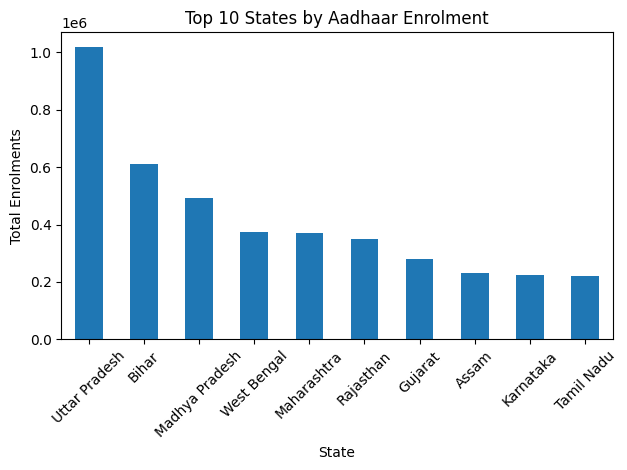

In [ ]:
import matplotlib.pyplot as plt

top_10_states = state_wise.head(10)

plt.figure()
top_10_states.plot(kind="bar")
plt.title("Top 10 States by Aadhaar Enrolment")
plt.xlabel("State")
plt.ylabel("Total Enrolments")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
age_group_totals = {
    "0–5": aadhaar_df["age_0_5"].sum(),
    "5–17": aadhaar_df["age_5_17"].sum(),
    "18+": aadhaar_df["age_18_greater"].sum()
}

age_group_totals


{'0–5': np.int64(3546965), '5–17': np.int64(1720384), '18+': np.int64(168353)}

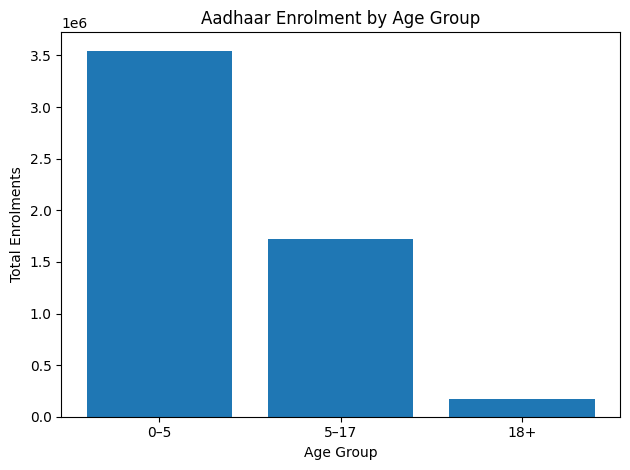

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(age_group_totals.keys(), age_group_totals.values())
plt.title("Aadhaar Enrolment by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Enrolments")
plt.tight_layout()
plt.show()


In [ ]:
aadhaar_df["date"] = pd.to_datetime(aadhaar_df["date"], dayfirst=True)


In [ ]:
time_trend = (
    aadhaar_df
    .groupby("date")["total_enrolment"]
    .sum()
    .sort_index()
)

time_trend.head()


,total_enrolment
date,
2025-03-02,109
2025-03-09,3404
2025-03-15,3102
2025-03-20,6218
2025-03-23,576


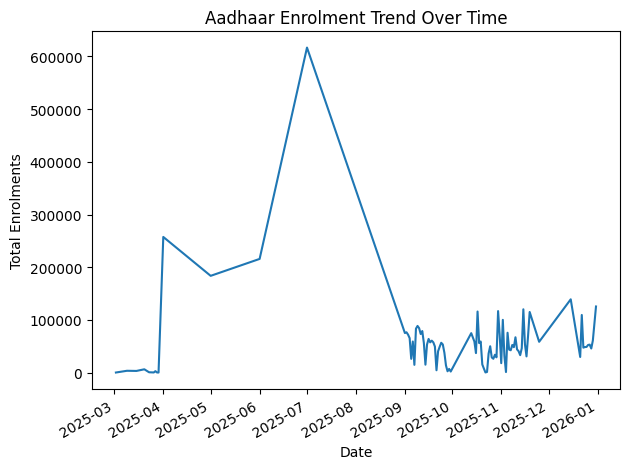

In [ ]:
plt.figure()
time_trend.plot()
plt.title("Aadhaar Enrolment Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Total Enrolments")
plt.tight_layout()
plt.show()


In [ ]:
clean_csv_path = "uidai_hackathon_dataset/aadhaar_enrolment_cleaned.csv"

aadhaar_df.to_csv(clean_csv_path, index=False)

clean_csv_path


'uidai_hackathon_dataset/aadhaar_enrolment_cleaned.csv'

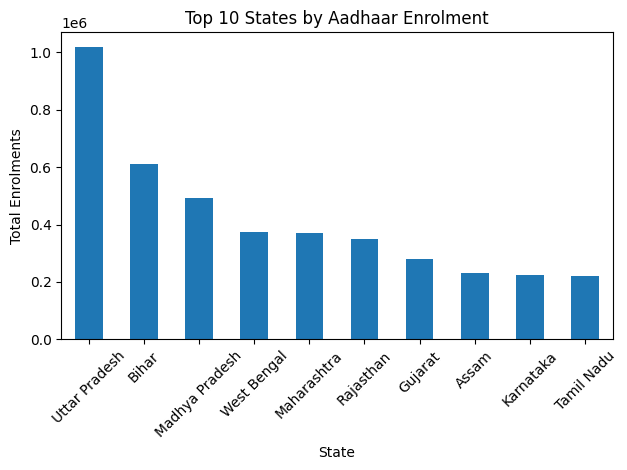

In [ ]:
plt.figure()
top_10_states.plot(kind="bar")
plt.title("Top 10 States by Aadhaar Enrolment")
plt.xlabel("State")
plt.ylabel("Total Enrolments")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("uidai_hackathon_dataset/state_wise_enrolment.png")
plt.show()


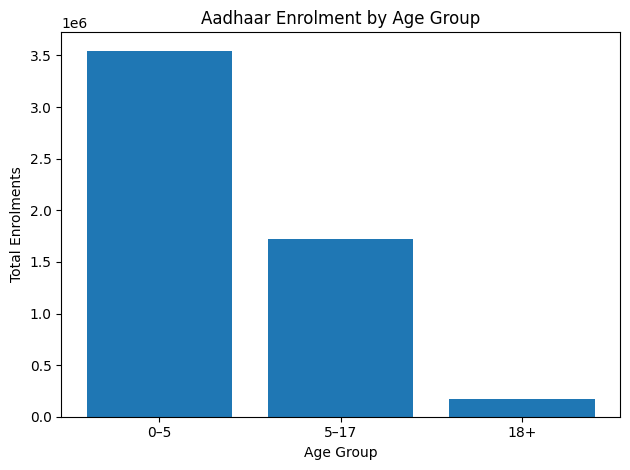

In [ ]:
plt.figure()
plt.bar(age_group_totals.keys(), age_group_totals.values())
plt.title("Aadhaar Enrolment by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Enrolments")
plt.tight_layout()
plt.savefig("uidai_hackathon_dataset/age_group_enrolment.png")
plt.show()


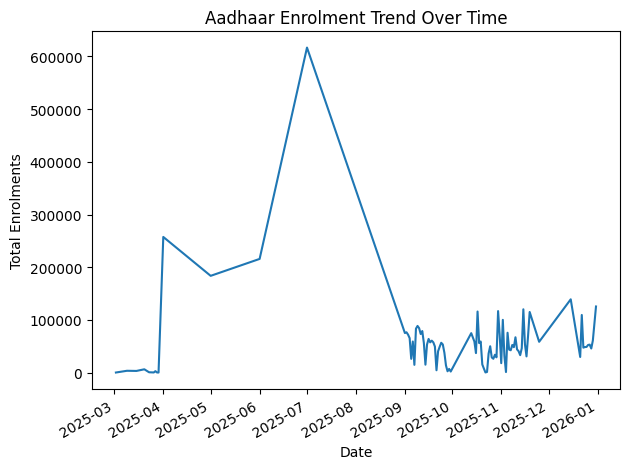

In [ ]:
plt.figure()
time_trend.plot()
plt.title("Aadhaar Enrolment Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Total Enrolments")
plt.tight_layout()
plt.savefig("uidai_hackathon_dataset/enrolment_trend.png")
plt.show()
